In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from pathlib import Path
from plotnine import scale_y_continuous
from plotnine import geom_vline, annotate


/home/alsayah/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/home/alsayah/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


# Load data

In [2]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [ ]:
adata_main = sc.read(merfish_path / "mouse_brain/WB_MERFISH_animal2_coronal.h5ad")

In [ ]:
adata_main

AnnData object with n_obs × n_vars = 215278 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'

In [104]:
adata = adata_main[adata_main.obs["brain_section_label"] == "C57BL6J-4.003"]

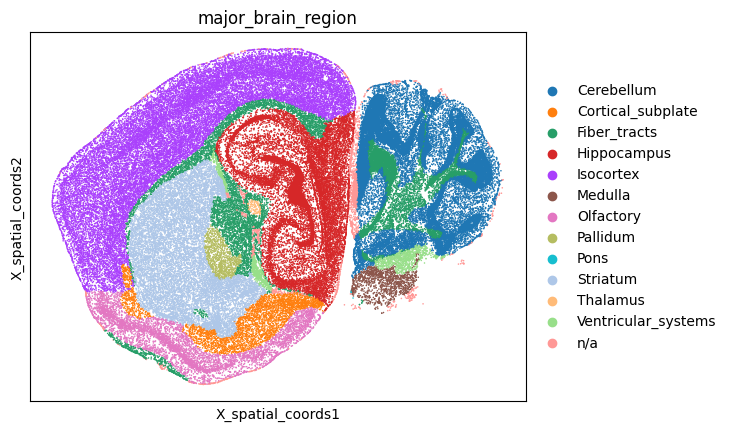

In [107]:
sc.pl.embedding(adata, basis="X_spatial_coords",color = "major_brain_region", s=5, use_raw=False)  # s = point size

# Basic QC

In [108]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [109]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

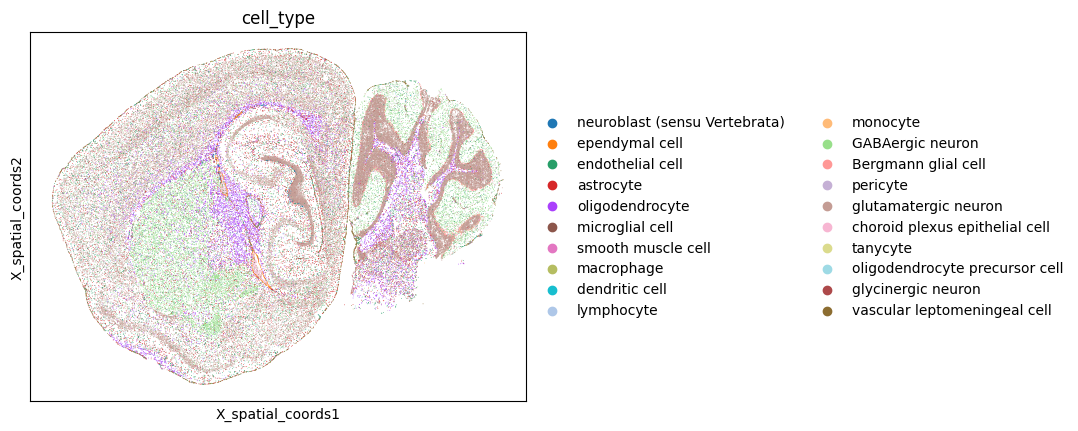

In [110]:
sc.pl.embedding(adata, basis="X_spatial_coords", color="cell_type")

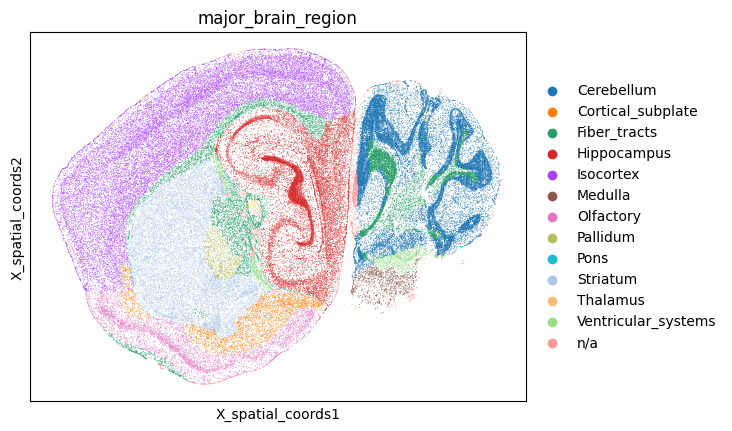

In [111]:
sc.pl.embedding(adata, basis="X_spatial_coords", color="major_brain_region")

# Calculate spatial connectivity matrix Wij

## Choose the right bandwith

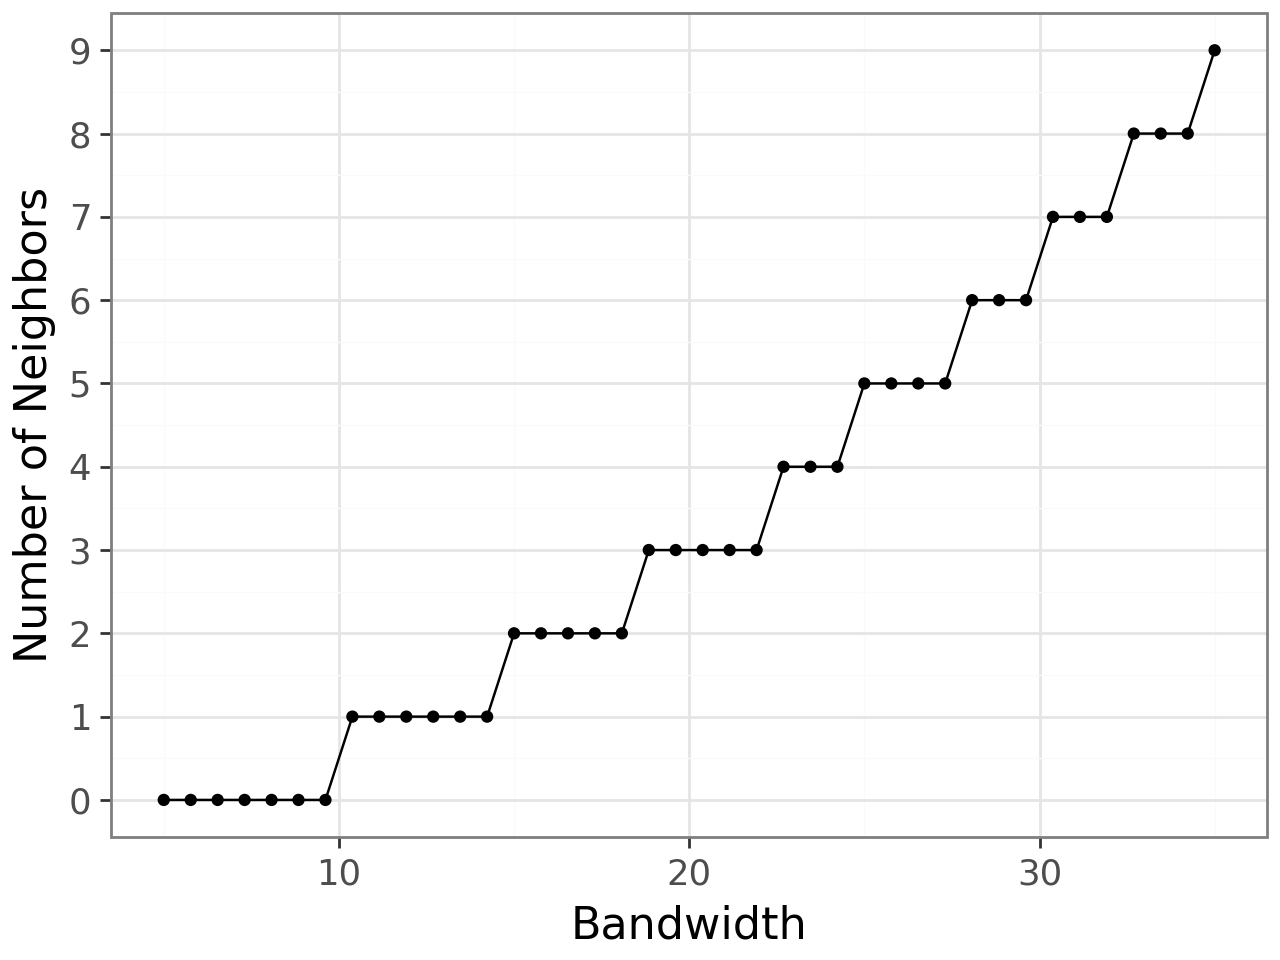

In [112]:
# around the sweet spot you explored
plot, df = li.ut.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,         
    end=35,           
    interval_n=40    
)
plot + scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

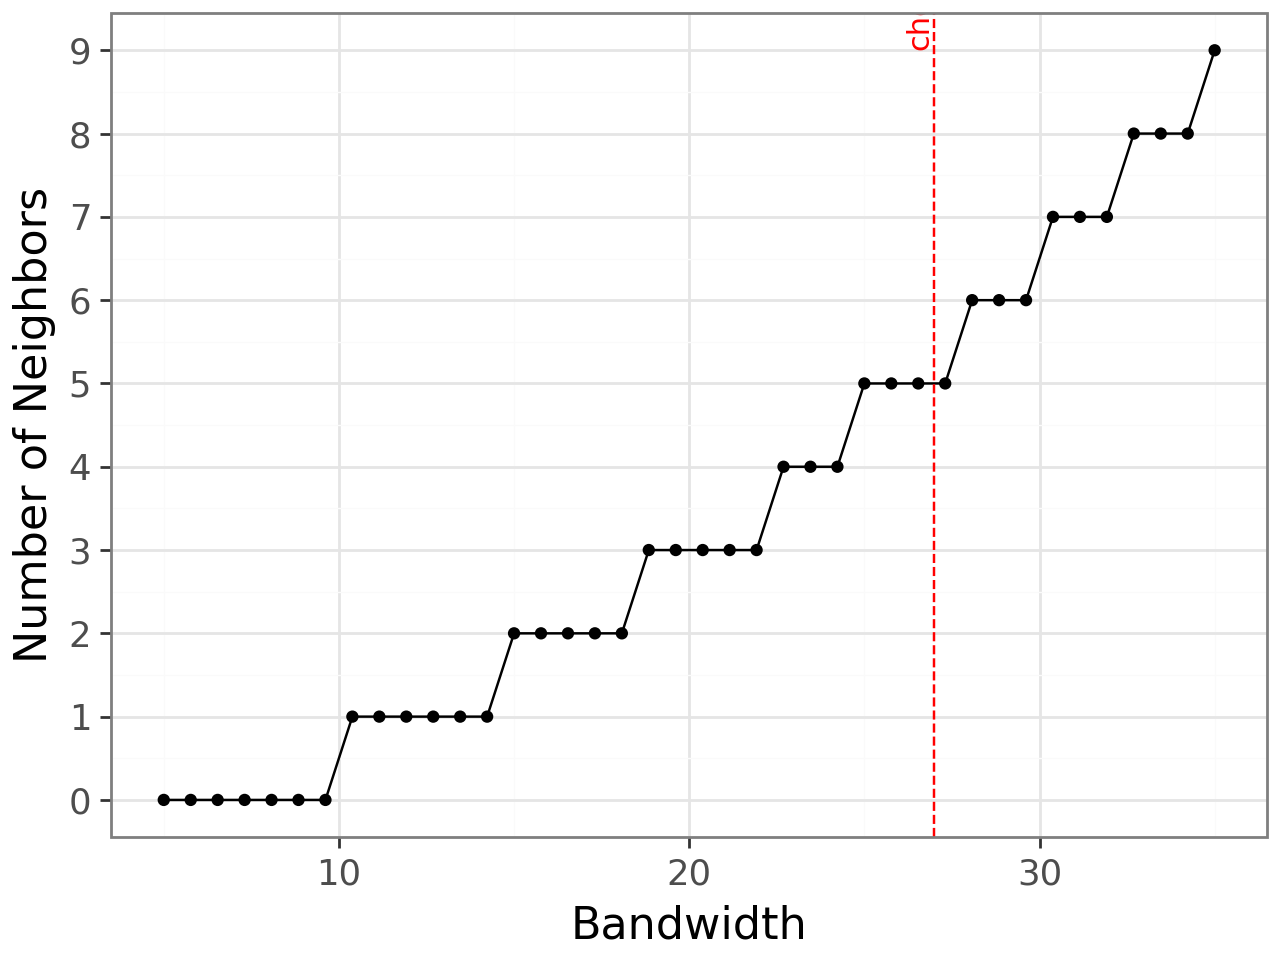

In [113]:
chosen = 27
plot + geom_vline(xintercept=chosen, linetype="dashed", color="red") + \
       annotate("text", x=chosen, y=df.neighbours.max(), 
                label=f"chosen={chosen}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

In [114]:
li.ut.spatial_neighbors(adata=adata, bandwidth=27, spatial_key="X_spatial_coords")

## Visualize proximity

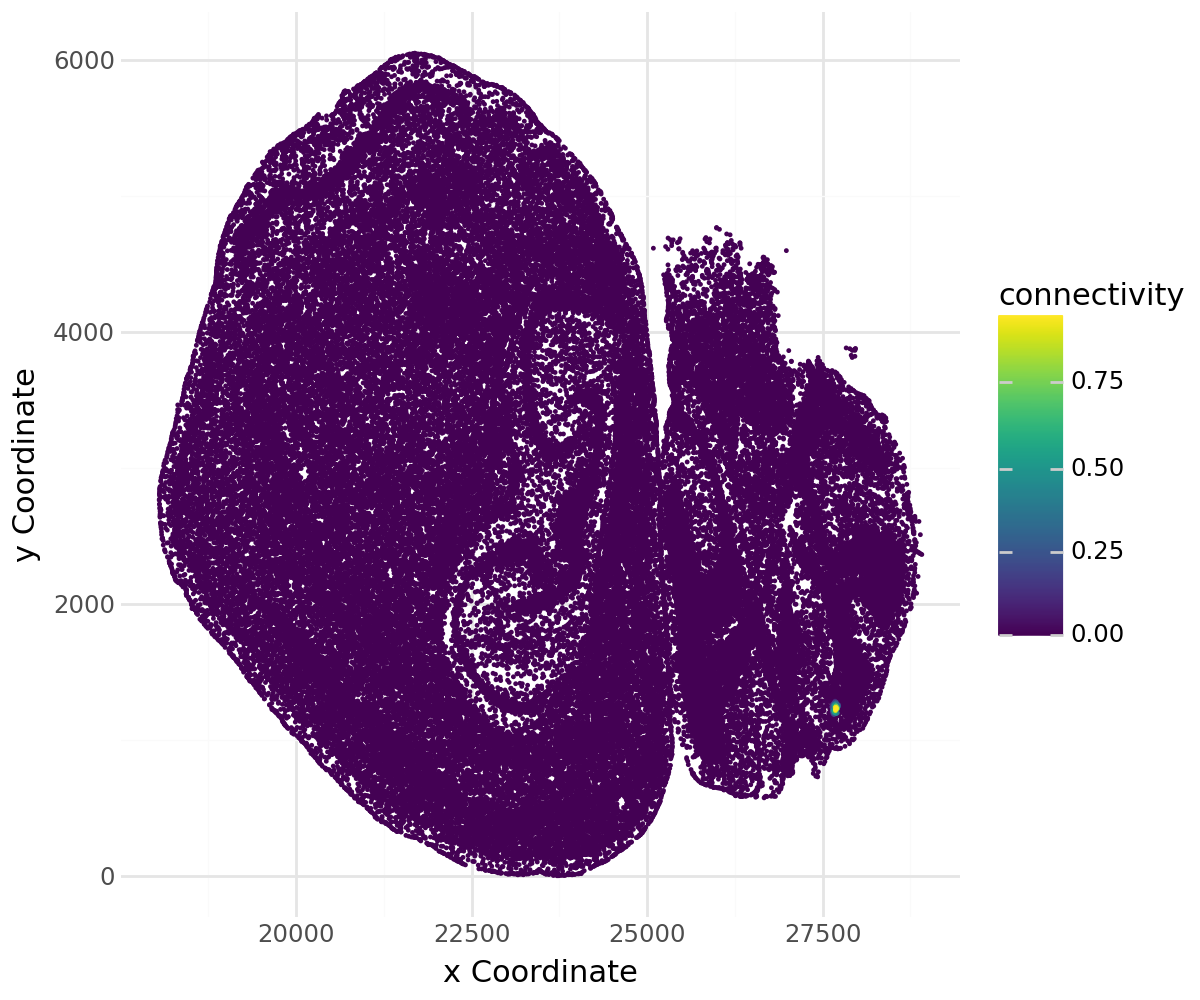

In [115]:
li.pl.connectivity(adata, idx=7000, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

## Find spatially variable genes (SVGs) using Morans'I

In [116]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, n_jobs = 10,
                       show_progress_bar=True)
adata.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
ENSMUSG00000031654,0.756366,0.000000,0.000001,0.000000
ENSMUSG00000032368,0.726687,0.000000,0.000001,0.000000
ENSMUSG00000020428,0.723643,0.000000,0.000001,0.000000
ENSMUSG00000055333,0.700703,0.000000,0.000001,0.000000
ENSMUSG00000003657,0.617964,0.000000,0.000001,0.000000
...,...,...,...,...
ENSMUSG00000060044,0.001294,0.129574,0.000001,0.130037
ENSMUSG00000029371,0.000979,0.195849,0.000001,0.196374
ENSMUSG00000040969,0.000796,0.242679,0.000001,0.243113
ENSMUSG00000055110,0.000731,0.260549,0.000001,0.260782


In [117]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1017

In [118]:
adata = adata[:, svgs]

# Inflow (Mouse)

## Convert gene from ENSEMBLE IDs to Symbol

In [119]:
import mygene
mg = mygene.MyGeneInfo()
query = mg.querymany(adata.var_names.tolist(),
                     scopes="ensembl.gene",
                     fields="symbol",
                     species="mouse")

# Make a mapping dictionary {ensembl_id: symbol}
mapping = {q['query']: q.get('symbol', q['query']) for q in query}
adata.var_names = [mapping.get(gid, gid) for gid in adata.var_names]

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-1000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 1001-1017 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.
2 input query terms found no hit:	['ENSMUSG00000113186', 'ENSMUSG00000109473']
Pass "returnall=True" to return complete lists of duplicate or missing query terms.


## Create mouse LR database

In [120]:
resource = li.rs.select_resource('consensus')
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})
# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse
mouse.tuples = list(zip(mouse["ligand"], mouse["receptor"]))

/g/stegle/aalsayah/repos/liana-py/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
/scratch/jobs/39365231/ipykernel_1181155/2507512555.py:17: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


## Run Inflow

In [121]:
lrdata = li.mt.inflow(adata,  
                                  groupby='cell_type', # cell type columns        
                                  interactions=mouse.tuples,                          
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(95103, 1637)

### Find spatially variable interactions (SVIs)

In [122]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

/home/alsayah/.local/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [123]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1380

In [124]:
lrdata = lrdata[:, svis]

## Filter

Cell should've at least 5 interactions, and interaction should exit in at least 5 cells

In [125]:
lrdata.shape

(95103, 1380)

In [126]:
sc.pp.filter_cells(lrdata, min_genes=5)
sc.pp.filter_genes(lrdata, min_cells=5)

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [127]:
lrdata.shape

(58706, 1339)

## Values distribution

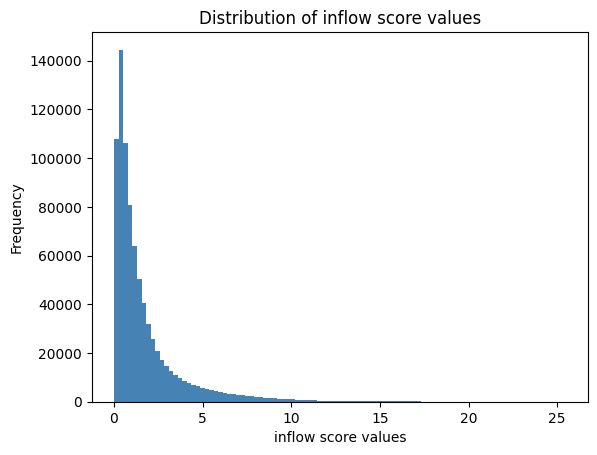

In [128]:
import scipy.sparse as sp

X = lrdata.X 
values = X.data


plt.hist(values, bins=100, color='steelblue')
plt.xlabel("inflow score values")
plt.ylabel("Frequency")
plt.title("Distribution of inflow score values")
plt.show()

In [129]:
lrdata

AnnData object with n_obs × n_vars = 58706 × 1339
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'tissue_colors', 'major_brain_region_colors', 'log1p', 'cell_type_colors', 'moranI'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    obsp: 'spatial_connectivities'

In [130]:
sc.pp.log1p(lrdata)

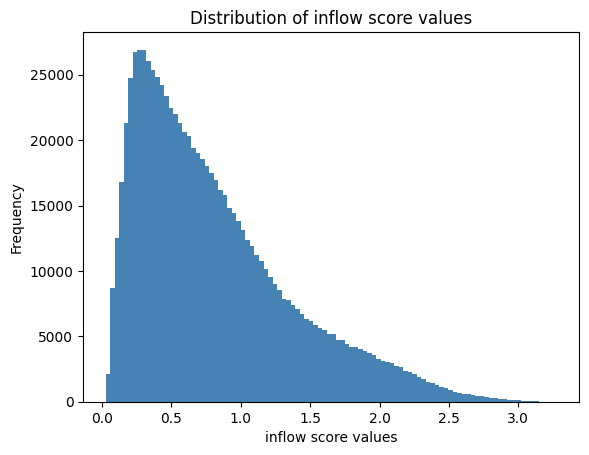

In [131]:

X = lrdata.X 
values = X.data


plt.hist(values, bins=100, color='steelblue')
plt.xlabel("inflow score values")
plt.ylabel("Frequency")
plt.title("Distribution of inflow score values")
plt.show()

## Find Global scores

In [132]:
li.mt.compute_global_score(lrdata, groupby='cell_type')

In [133]:
lrdata.uns["global_score"].sort_values('lr_mean').tail(20)

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
20166,Sfrp1,Sfrp1,Fzd2,Fzd2,choroid plexus epithelial cell,choroid plexus epithelial cell,0.627976
8181,Col18a1,Col18a1,Gpc4,Gpc4,smooth muscle cell,smooth muscle cell,0.631086
24134,Fgf1,Fgf1,Egfr,Egfr,vascular leptomeningeal cell,vascular leptomeningeal cell,0.631212
13138,Fn1,Fn1,Cd44,Cd44,endothelial cell,lymphocyte,0.640045
16068,Ntf3,Ntf3,Ntrk3,Ntrk3,glutamatergic neuron,Bergmann glial cell,0.643690
1341,Col18a1,Col18a1,Gpc4,Gpc4,choroid plexus epithelial cell,ependymal cell,0.646920
14259,Fgf1,Fgf1,Cd44,Cd44,astrocyte,monocyte,0.647011
24172,Dcn,Dcn,Egfr,Egfr,vascular leptomeningeal cell,vascular leptomeningeal cell,0.672117
8498,Fn1,Fn1,Itga9,Itga9,endothelial cell,smooth muscle cell,0.676706
24132,Wnt5a,Wnt5a,Fzd2,Fzd2,vascular leptomeningeal cell,vascular leptomeningeal cell,0.683493


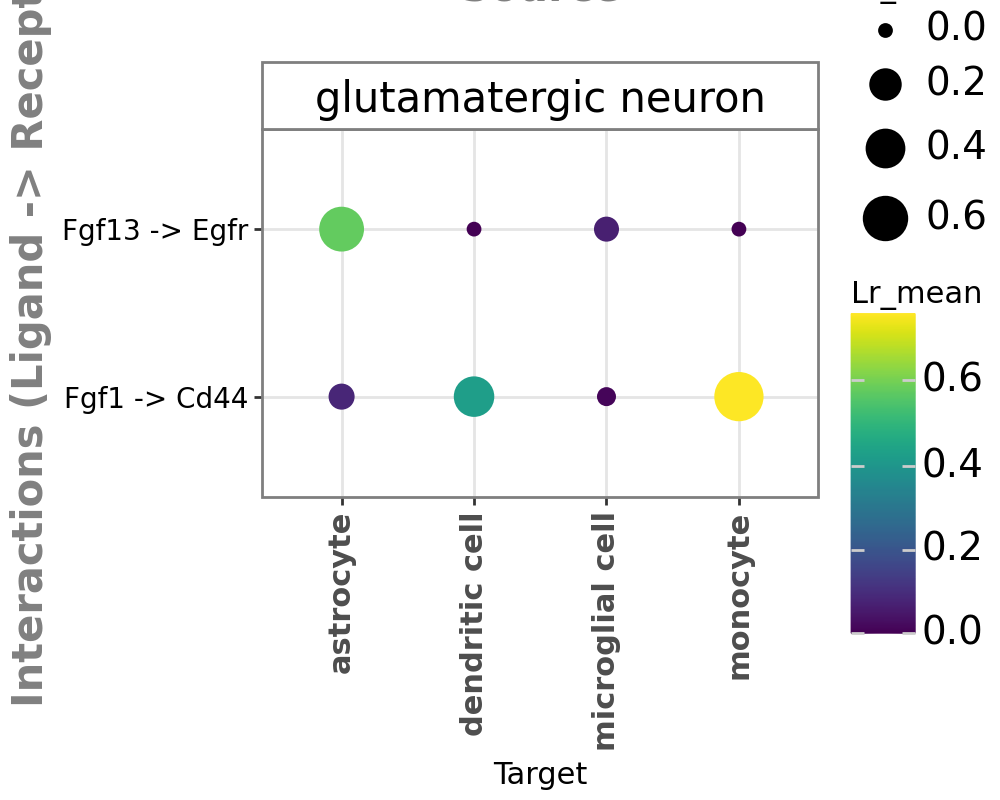

In [135]:
li.pl.dotplot(adata = lrdata, 
              colour='lr_mean',
              size = "lr_mean",
              source_labels=['glutamatergic neuron'],
              target_labels=[ "monocyte", "microglial cell", "dendritic cell", "astrocyte"],
              filter_fun=lambda x: x['lr_mean'] > 0.5,
              figure_size=(5, 4),
              uns_key='global_score' 
             )

## Visualize interaction

In [136]:
lrdata.layers['transformed'] = li.utils.zi_minmax(lrdata.X, cutoff=0.01)

In [137]:
lrdata.var_names

Index(['glutamatergic neuron^Ntf3^Ntrk3', 'glutamatergic neuron^Efna5^Epha4',
       'choroid plexus epithelial cell^Col18a1^Gpc4',
       'neuroblast (sensu Vertebrata)^Ntf3^Ntrk3',
       'Bergmann glial cell^Ntf3^Ntrk3', 'lymphocyte^Efna5^Epha4',
       'choroid plexus epithelial cell^Crh^Crhr2',
       'glutamatergic neuron^Trh^Trhr',
       'neuroblast (sensu Vertebrata)^Wnt5a^Epha7',
       'GABAergic neuron^Efna5^Epha8',
       ...
       'oligodendrocyte^Sema5a^Met',
       'vascular leptomeningeal cell^Fgf13^Scn5a', 'astrocyte^Rspo2^Lgr6',
       'glutamatergic neuron^Tgfb2^Acvr1c_Tgfbr2',
       'choroid plexus epithelial cell^Hdc^Hrh2',
       'microglial cell^Gpc3^Tnfrsf11b',
       'choroid plexus epithelial cell^Thbs4^Cd36',
       'GABAergic neuron^Efna5^Epha1', 'oligodendrocyte^Crh^Crhr2',
       'oligodendrocyte^Tac2^Tacr3'],
      dtype='object', length=1339)

In [138]:
interaction = "glutamatergic neuron^Ntf3^Ntrk3"
parts = interaction.split("^")
cell_type_col = "cell_type"
comp = interaction.split("^")
spatial_key = "X_spatial_coords"

In [139]:
gene_expr = lrdata[:, interaction].X

In [140]:
# If X is sparse, convert to dense
if hasattr(gene_expr, "toarray"):
    gene_expr = gene_expr.toarray()

# Count how many cells have expression > 0
n_expressing = np.sum(gene_expr > 0)

print(f"{interaction} is expressed in {n_expressing} cells.")

glutamatergic neuron^Ntf3^Ntrk3 is expressed in 18483 cells.


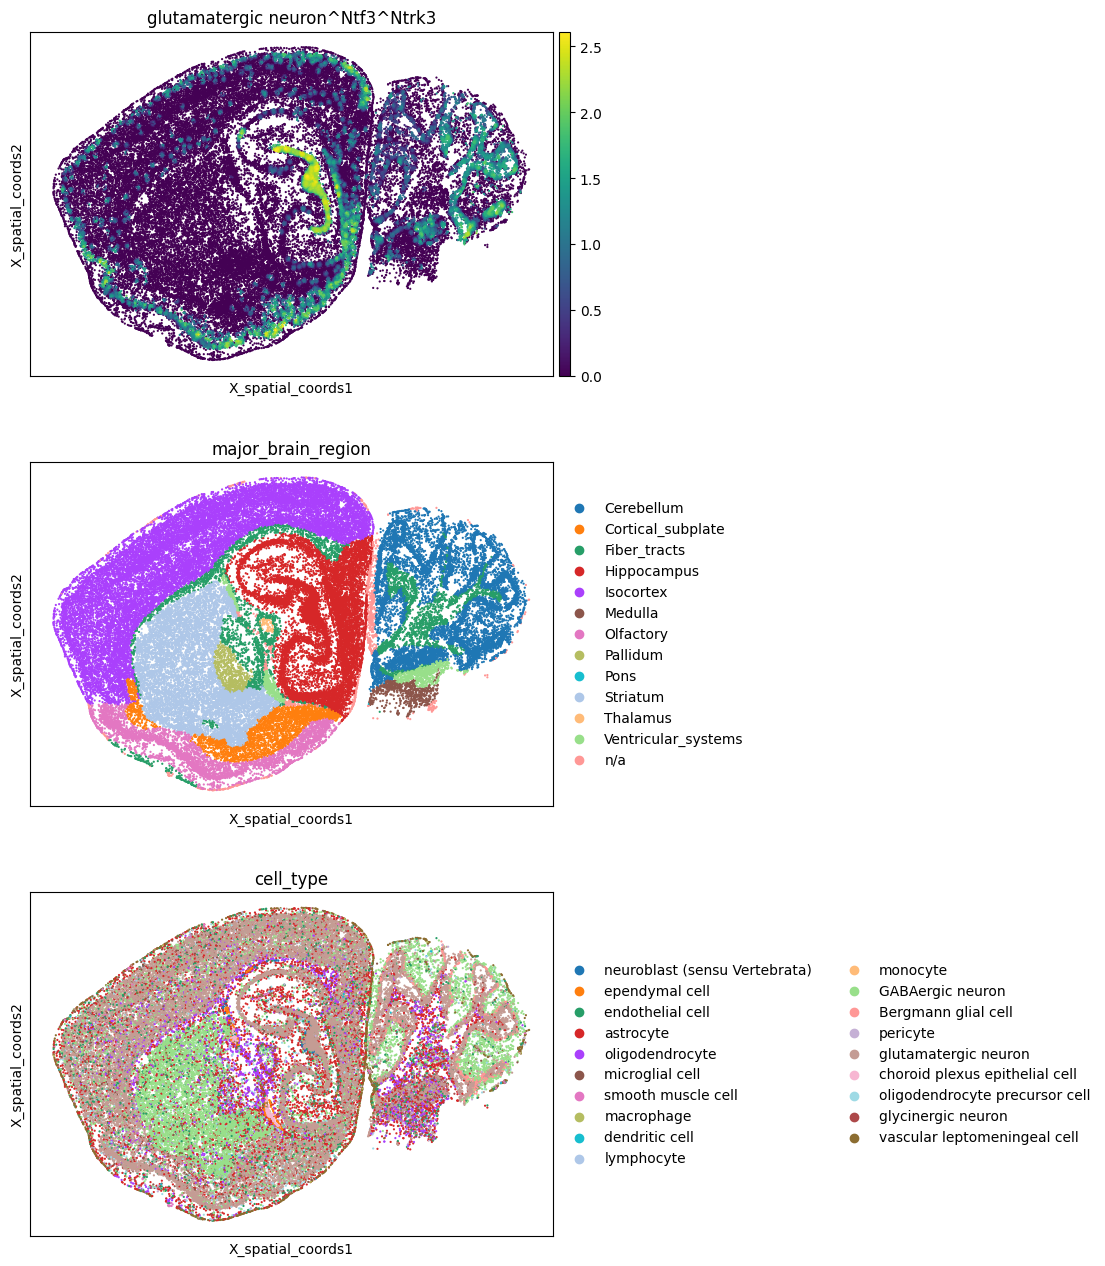

In [141]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=[interaction, "major_brain_region", "cell_type" ],
    s=10,
    ncols=1
)

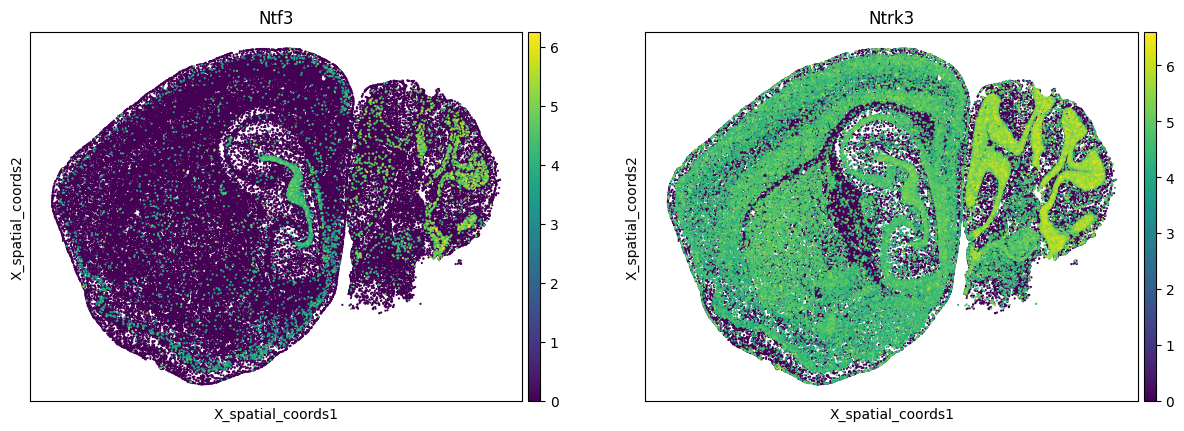

In [142]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[parts[1], parts[2]],
    s=10,
    use_raw=False
)

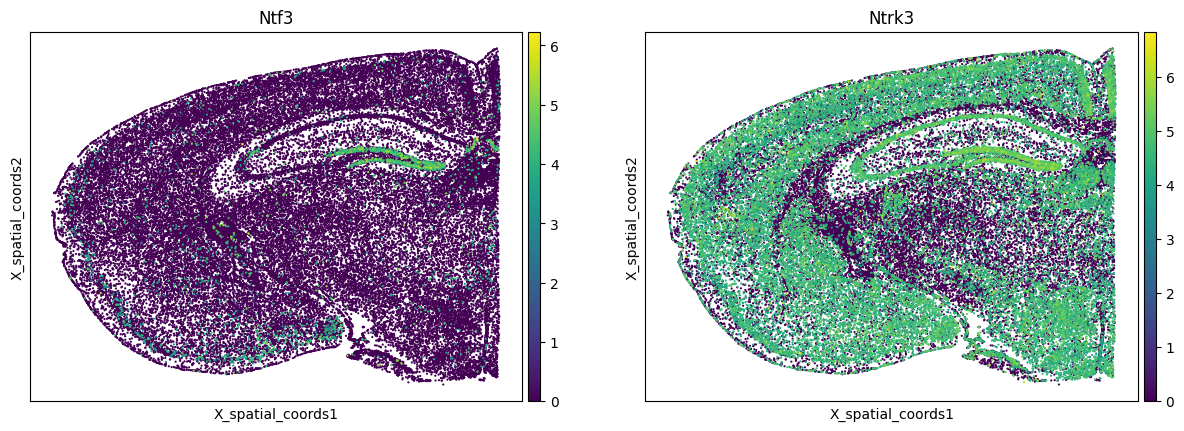

In [61]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[parts[1], parts[2]],
    s=10,
    use_raw=False
)

### Reciver cell types per region

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- helpers
def _as_list(x):
    if isinstance(x, (list, tuple, np.ndarray, pd.Index)):
        return list(x)
    return [x]

def global_y_lims(adata, keys):
    """
    Compute global y-limits for each key across the WHOLE dataset,
    so all regions share the same scales per panel.
    Works whether keys are var_names (genes) or .obs columns.
    """
    keys = _as_list(keys)
    ymins, ymaxs = [], []
    for k in keys:
        if k in adata.obs.columns:
            vals = adata.obs[k].to_numpy()
        else:
            vals = adata.to_df()[k].to_numpy()  # gene in var_names
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            ymins.append(0.0); ymaxs.append(1.0)
        else:
            ymins.append(np.nanmin(vals))
            ymaxs.append(np.nanmax(vals))
    return list(zip(ymins, ymaxs))  # [(ymin,ymax) per key]

def add_n_to_xticklabels(ax, counts_by_group):
    """
    Add '(n=..)' to x tick labels for a single axis.
    counts_by_group: dict {group: n}
    """
    ticks = ax.get_xticks()
    labels = [tick.get_text() for tick in ax.get_xticklabels()]
    # Matplotlib sometimes empties labels until draw; fall back to category order in counts
    if not any(labels):
        labels = list(counts_by_group.keys())
    new_labels = []
    for lab in labels:
        g = lab
        n = counts_by_group.get(g, 0)
        new_labels.append(f"{lab}\n(n={n})")
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels, rotation=90, ha="center")

def cliffs_delta(x, y):
    """
    Cliff's delta: delta = ( (#x>y - #x<y) ) / (len(x)*len(y)).
    Returns delta in [-1, 1] and a magnitude label (per Romano et al. common cutoffs).
    """
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan, "NA"
    # Efficient pairwise compare via sorting
    x_sorted = np.sort(x)
    y_sorted = np.sort(y)

    # Count # of y less than each x and # greater than each x using searchsorted
    import bisect
    greater = 0
    less = 0
    for xi in x_sorted:
        less += np.searchsorted(y_sorted, xi, side="left")
        greater += ny - np.searchsorted(y_sorted, xi, side="right")
    delta = (greater - less) / (nx * ny)

    # magnitude bins (you can tweak cutoffs if you prefer Vargha–Delaney A)
    ad = abs(delta)
    if ad < 0.147: mag = "negligible"
    elif ad < 0.33: mag = "small"
    elif ad < 0.474: mag = "medium"
    else: mag = "large"
    return float(delta), mag

def summarize_by_region_celltype(adata, keys, region_col, cell_type_col, threshold=0.05):
    """
    For each key (feature), region, and cell type: median, 90th pct, % > threshold, counts.
    Adds ranks within-region and across-regions (by median).
    Returns a tidy DataFrame.
    """
    keys = _as_list(keys)
    frames = []
    # choose source for keys
    df_all = adata.to_df()  # genes
    obs = adata.obs

    for k in keys:
        if k in obs.columns:
            vals = obs[k]
        else:
            vals = df_all[k]

        tmp = pd.DataFrame({
            region_col: obs[region_col].values,
            cell_type_col: obs[cell_type_col].values,
            k: vals.values
        }).dropna(subset=[region_col, cell_type_col, k])

        g = tmp.groupby([region_col, cell_type_col], observed=True)[k]
        out = g.agg(
            n="size",
            median="median",
            p90=lambda s: np.percentile(s, 90),
            pct_gt=lambda s: (np.asarray(s) > threshold).mean() * 100.0
        ).reset_index()
        out["key"] = k

        # ranks by median (1 = highest)
        out["rank_within_region_by_median"] = out.groupby(region_col, observed=True)["median"].rank(ascending=False, method="min")
        # across regions: rank cell types globally per key, still useful for quick scan
        out["rank_across_regions_by_median"] = out.groupby(["key"], observed=True)["median"].rank(ascending=False, method="min")

        frames.append(out)

    res = pd.concat(frames, ignore_index=True)
    # Sort for readability
    res = res.sort_values(["key", region_col, "median"], ascending=[True, True, False], kind="stable")
    return res.rename(columns={"p90": "p90", "pct_gt": f"pct_gt_{threshold}"})

def effect_sizes_vs_rest(adata, keys, region_col, cell_type_col):
    """
    For each region & key & cell type: Cliff's delta of (cell type) vs (all other cell types in same region).
    Also computes Mann–Whitney U p-value and BH-FDR per (region,key) family.
    Returns a tidy DataFrame with delta, magnitude, U, p, q (FDR).
    """
    keys = _as_list(keys)
    df_all = adata.to_df()
    obs = adata.obs

    rows = []
    for region in obs[region_col].dropna().unique():
        region_mask = (obs[region_col] == region)
        ct_series = obs.loc[region_mask, cell_type_col]
        cts = ct_series.dropna().unique()
        for k in keys:
            if k in obs.columns:
                vals = obs.loc[region_mask, k].to_numpy()
            else:
                vals = df_all.loc[region_mask, k].to_numpy()
            ct_vec = ct_series.to_numpy()

            # compute for each cell type in this region
            for ct in cts:
                in_mask = (ct_vec == ct)
                x = vals[in_mask]
                y = vals[~in_mask]

                # Cliff's delta
                delta, mag = cliffs_delta(x, y)

                # Mann-Whitney U (two-sided) for p-value
                if np.isfinite(delta) and x.size > 0 and y.size > 0:
                    try:
                        U, p = mannwhitneyu(x, y, alternative="two-sided")
                    except ValueError:
                        U, p = np.nan, np.nan
                else:
                    U, p = np.nan, np.nan

                rows.append({
                    "region": region,
                    "key": k,
                    "cell_type": ct,
                    "n_in": int(x.size),
                    "n_out": int(y.size),
                    "cliffs_delta": delta,
                    "magnitude": mag,
                    "mwU": U,
                    "pval": p,
                })

    ef = pd.DataFrame(rows)

    # BH-FDR within each (region, key) family of tests
    def _fdr(group):
        p = group["pval"].to_numpy()
        # handle all-nan case
        if np.all(~np.isfinite(p)):
            group["qval"] = np.nan
        else:
            p_clean = np.where(np.isfinite(p), p, 1.0)
            _, q, _, _ = multipletests(p_clean, method="fdr_bh")
            # restore NaNs to q where p was NaN
            q = np.where(np.isfinite(p), q, np.nan)
            group["qval"] = q
        return group

    ef = ef.groupby(["region", "key"], group_keys=False).apply(_fdr)
    ef["significant_fdr_5pct"] = ef["qval"] < 0.05
    ef = ef.sort_values(["key", "region", "qval", "cliffs_delta"], ascending=[True, True, True, False], kind="stable")
    return ef

In [67]:
def plot_region_violins_with_fixed_ylim(
    adata, keys, region_col, cell_type_col,
    title_prefix="Region", add_counts=True,
    expr_threshold=0.05, prop_digits=2
):
    """
    Plots violins per region with identical y-limits per key.
    Tick labels show per-cell-type counts AND proportion expressing (> expr_threshold):
        'CellType (n=500, p=0.50)'
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import scanpy as sc

    def _as_list(x):
        if isinstance(x, (list, tuple, np.ndarray, pd.Index)):
            return list(x)
        return [x]

    def global_y_lims(adata, keys):
        keys = _as_list(keys)
        ymins, ymaxs = [], []
        df_all = adata.to_df()
        for k in keys:
            if k in adata.obs.columns:
                vals = adata.obs[k].to_numpy()
            else:
                vals = df_all[k].to_numpy()
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                ymins.append(0.0); ymaxs.append(1.0)
            else:
                ymins.append(np.nanmin(vals))
                ymaxs.append(np.nanmax(vals))
        return list(zip(ymins, ymaxs))

    def add_label_n_and_p(ax, labels_order, n_exp, p_prop):
        # labels_order is a list of group names in the axis order
        new_labels = []
        for g in labels_order:
            ne = int(n_exp.get(g, 0))
            pp = float(p_prop.get(g, 0.0))
            new_labels.append(f"{g}\n(n={ne}, p={pp:.{prop_digits}f})")
        ax.set_xticklabels(new_labels, rotation=90, ha="center")

    def get_values(adata, key):
        # helper to fetch a vector for 'key' from X (genes) or obs
        if key in adata.obs.columns:
            return adata.obs[key].to_numpy()
        return adata.to_df()[key].to_numpy()

    keys_list = _as_list(keys)
    ylims = global_y_lims(adata, keys_list)

    for region in adata.obs[region_col].dropna().unique():
        ad = adata[adata.obs[region_col] == region]
        # filter out small cell types (<5% of region total)
        region_total = ad.n_obs
        counts = ad.obs[cell_type_col].value_counts()
        keep_ct = counts[counts >= 0.05 * region_total].index
        ad = ad[ad.obs[cell_type_col].isin(keep_ct)]


        ax = sc.pl.violin(
            ad,
            keys=keys_list,
            groupby=cell_type_col,
            use_raw=False,
            show=False,
            stripplot=False,
            scale="width",
        )

        axes = ax if isinstance(ax, (list, np.ndarray)) else [ax]
        axes = np.array(axes).ravel().tolist()

        # Precompute totals per group in this region (denominator for p)
        totals_by_group = ad.obs.groupby(cell_type_col, observed=True).size()

        # For each axis (key), compute expressing counts and proportions, then label
        for i, axi in enumerate(axes):
            # y-lims (consistent across regions for this key)
            if i < len(ylims):
                lo, hi = ylims[i]
                span = hi - lo
                axi.set_ylim(lo - 0.02 * span, hi + 0.02 * span)

            if add_counts:
                k = keys_list[i] if i < len(keys_list) else keys_list[-1]
                vals_k = get_values(ad, k)

                # Boolean expressing mask per cell (value > threshold)
                expr_mask = np.isfinite(vals_k) & (vals_k > expr_threshold)

                # Build a per-cell DataFrame (group & expr flag) for aggregation
                g_series = ad.obs[cell_type_col].astype(str)
                # counts expressing per group
                n_exp = g_series[expr_mask].value_counts()
                # ensure all groups present
                n_exp = n_exp.reindex(totals_by_group.index.astype(str), fill_value=0)

                # proportions per group
                p_prop = (n_exp / totals_by_group.astype(float)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

                # Determine axis order of groups
                tick_texts = [t.get_text() for t in axi.get_xticklabels()]
                if any(tick_texts):
                    labels_order = [t.split("\n")[0] for t in tick_texts]  # strip previous decorations
                else:
                    labels_order = list(totals_by_group.index.astype(str))

                add_label_n_and_p(axi, labels_order, n_exp.to_dict(), p_prop.to_dict())

        plt.gcf().suptitle(f"{title_prefix}: {region}", y=0.98)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


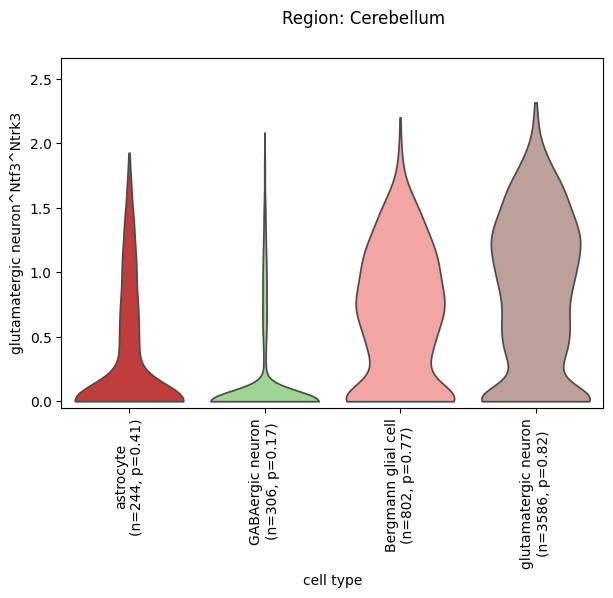

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


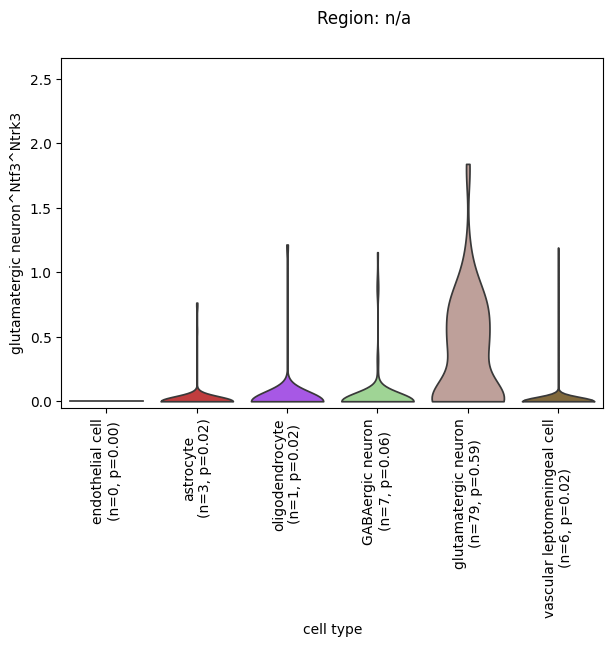

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


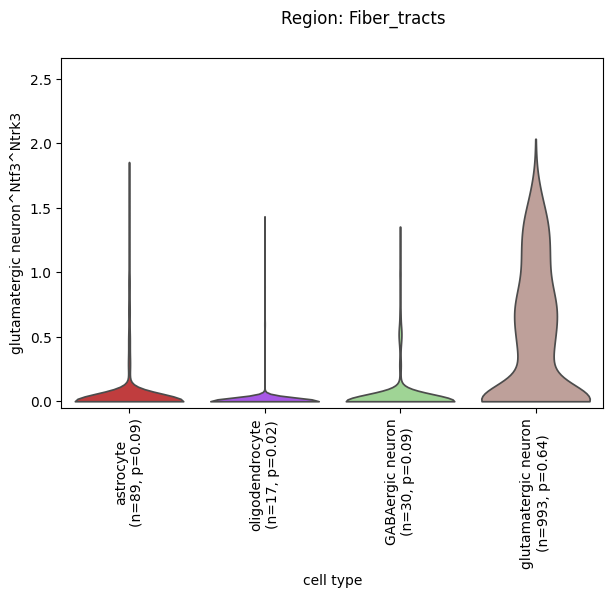

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


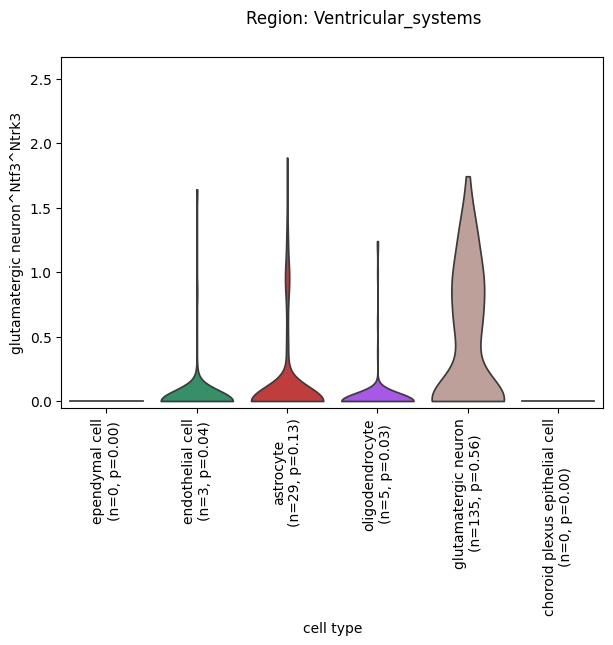

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


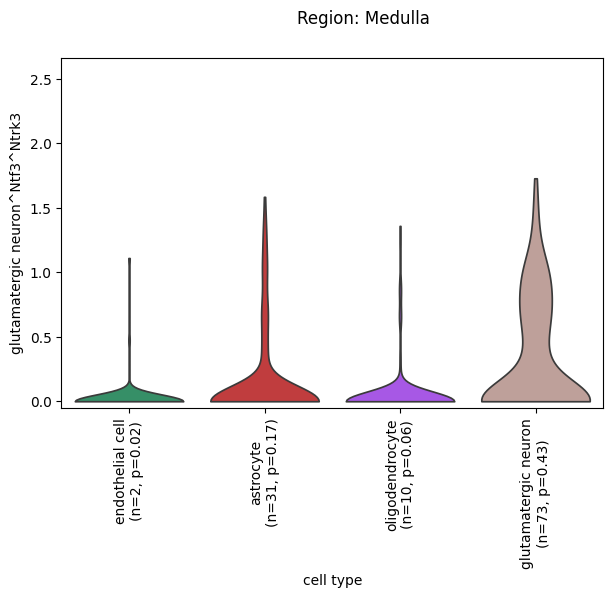

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


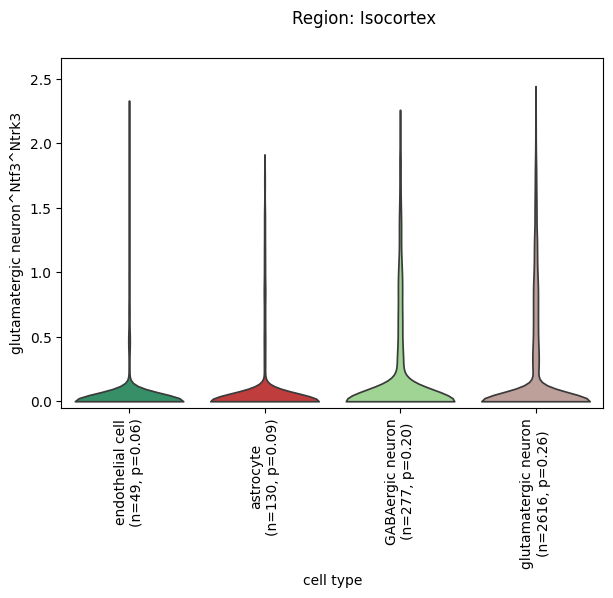

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


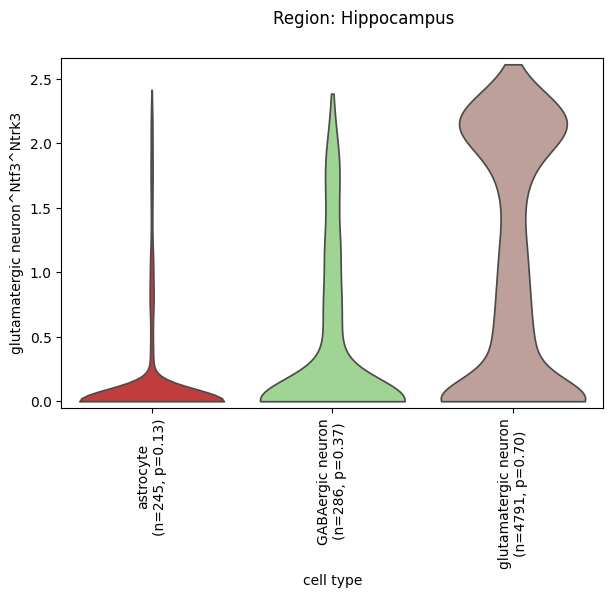

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


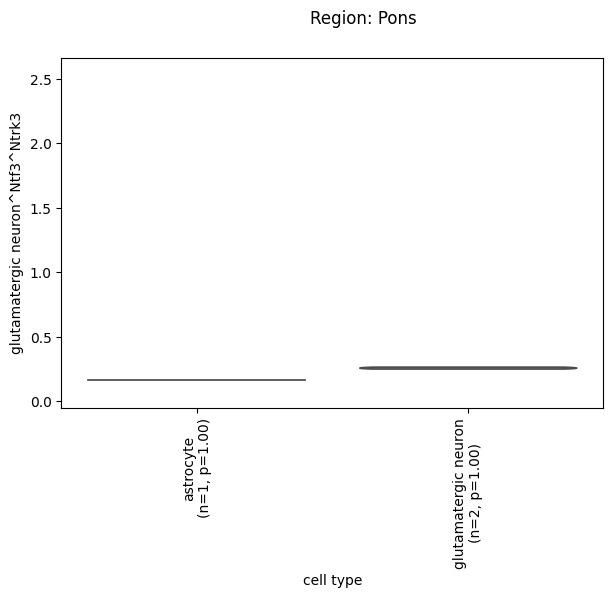

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


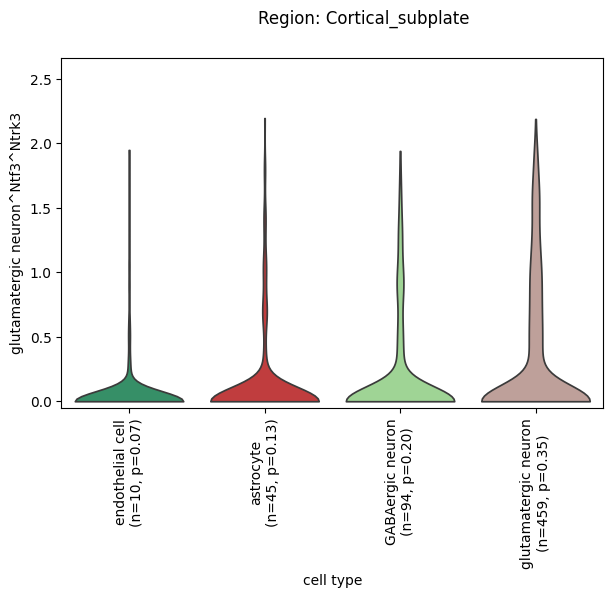

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


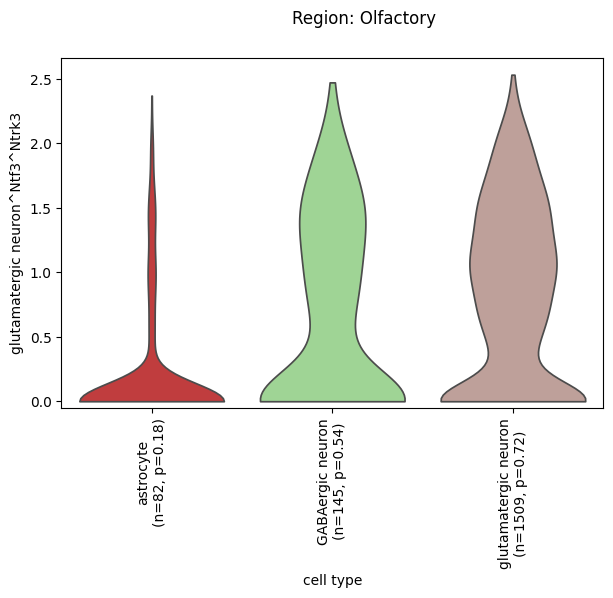

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


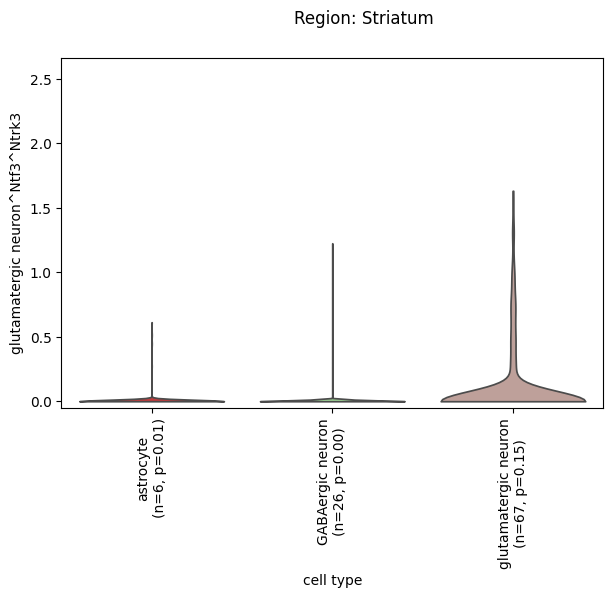

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


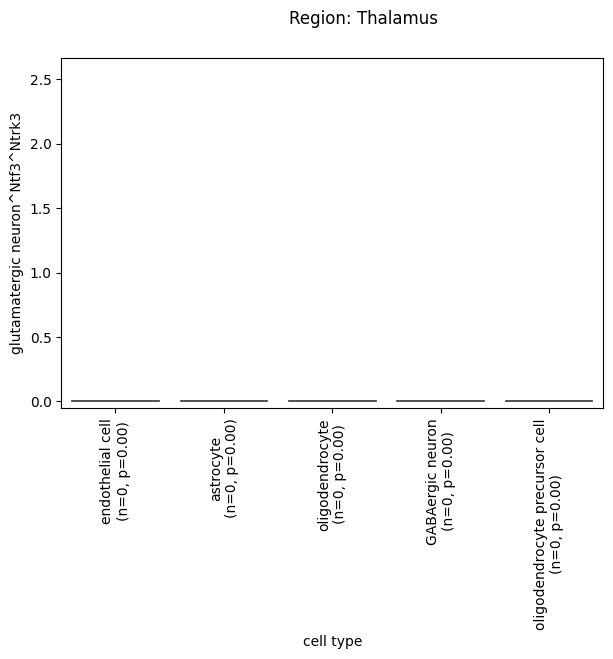

/home/alsayah/.local/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: `scale` is deprecated, use `density_norm` instead
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/39365231/ipykernel_1181155/3632055410.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


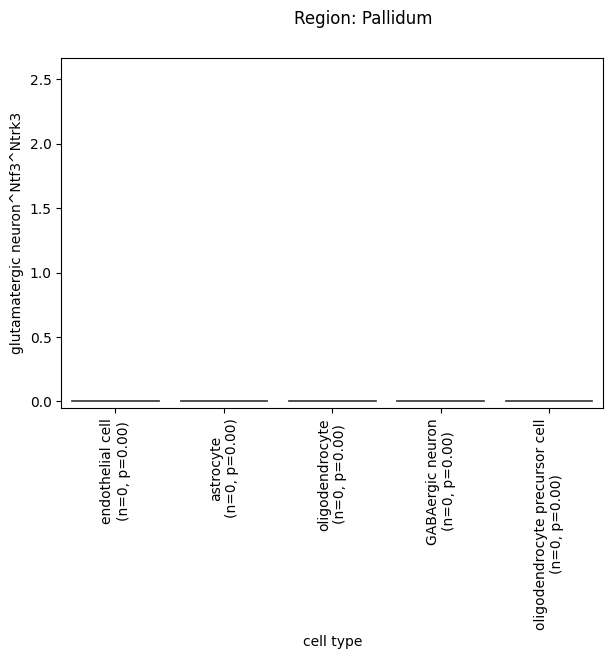

In [143]:
plot_region_violins_with_fixed_ylim(
    lrdata,
    keys=interaction,                
    region_col="major_brain_region",
    cell_type_col=cell_type_col,
    title_prefix="Region",
    add_counts=True,
    expr_threshold=0.05,              
    prop_digits=2                     
)

### Plot sender^L^R^reciver cell type

In [80]:
lrdata.obs["major_brain_region"].value_counts()

major_brain_region
Isocortex              10467
Thalamus                5366
Hippocampus             4674
Hypothalamus            3769
Fiber_tracts            2871
Cortical_subplate       2316
Striatum                2031
Olfactory               1400
Ventricular_systems     1138
Name: count, dtype: int64

In [ ]:
hippo = 

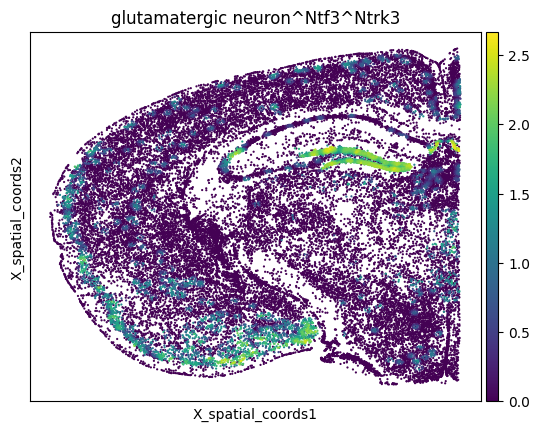

In [78]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=interaction,
    s=10,
    use_raw=False
)

In [144]:
# Define the subset condition
highlight = (
    (lrdata.obs["major_brain_region"] == "Hippocampus") &
    (lrdata.obs["cell_type"] == "astrocyte")
)

# Create a new column for plotting
lrdata.obs["highlight_group"] = "Other cells"
lrdata.obs.loc[highlight, "highlight_group"] = "Hippocampus astrocyte"


... storing 'highlight_group' as categorical


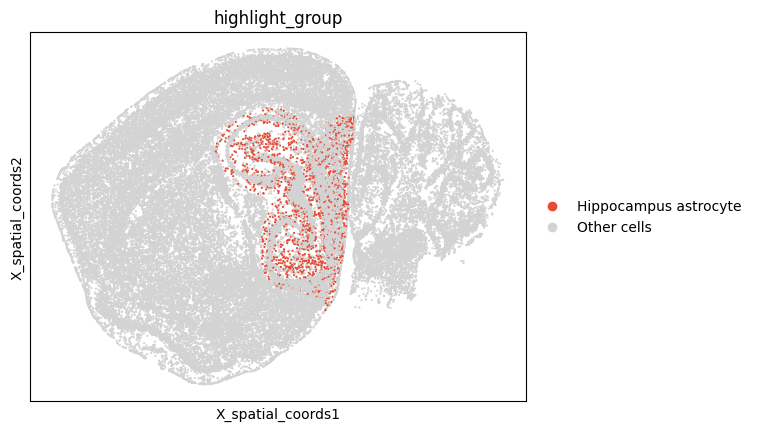

In [145]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color="highlight_group",
    palette=["#E64B35", "lightgrey"],  # grey for background, red for highlight
    s=10,
    use_raw=False
)


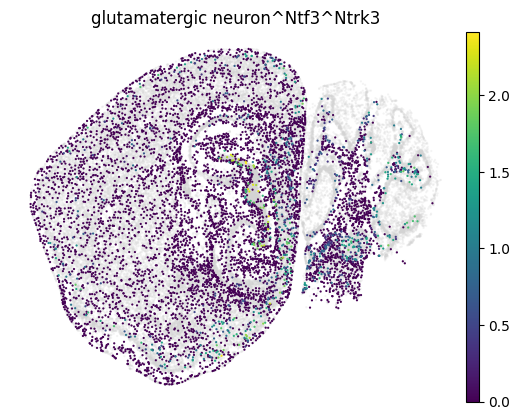

In [146]:
import scanpy as sc

is_astro = lrdata.obs["cell_type"].eq("astrocyte")

# base layer: everyone in grey (faded)
ax = sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=None,         # just coordinates
    s=10,
    alpha=0.25,         # fade background
    frameon=False,
    show=False
)

# top layer: only astrocytes, colored by expression
sc.pl.embedding(
    lrdata[is_astro],
    basis=spatial_key,
    color=interaction,  # e.g. a gene or score in .var
    s=10,
    use_raw=False,
    ax=ax,
    # optional:
    # color_map="viridis", vmin=None, vmax=None
)


In [91]:
lrdata.obs["cell_type"].value_counts()

cell_type
glutamatergic neuron              16996
astrocyte                          4909
GABAergic neuron                   4648
oligodendrocyte                    2006
endothelial cell                   1537
vascular leptomeningeal cell       1164
oligodendrocyte precursor cell     1014
microglial cell                     861
choroid plexus epithelial cell      546
ependymal cell                      447
pericyte                            383
neuroblast (sensu Vertebrata)       286
smooth muscle cell                  234
tanycyte                            158
macrophage                          110
lymphocyte                           17
dopaminergic neuron                  14
histaminergic neuron                 13
dendritic cell                       12
glycinergic neuron                    4
monocyte                              1
Name: count, dtype: int64

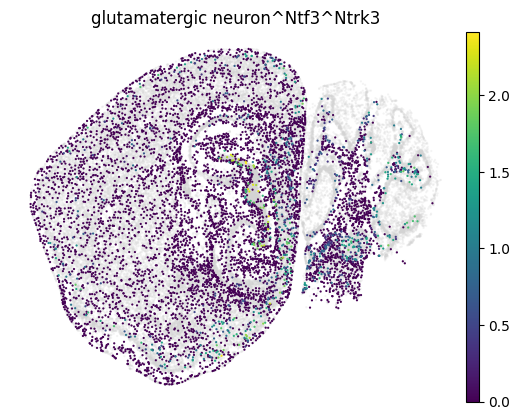

In [147]:
import scanpy as sc

is_astro = lrdata.obs["cell_type"].eq("astrocyte")

# base layer: everyone in grey (faded)
ax = sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=None,         # just coordinates
    s=10,
    alpha=0.25,         # fade background
    frameon=False,
    show=False
)

# top layer: only astrocytes, colored by expression
sc.pl.embedding(
    lrdata[is_astro],
    basis=spatial_key,
    color=interaction,  # e.g. a gene or score in .var
    s=10,
    use_raw=False,
    ax=ax,
    # optional:
    # color_map="viridis", vmin=None, vmax=None
)
